In [1]:
#!pip install anaconda netcdf4 h5netcdf scipy pydap zarr fsspec cftime rasterio cfgrib pooch
#!pip install "xarray[netCDF4, h5netcdf, scipy, pydap, zarr, fsspec, cftime, rasterio, cfgrib, pooch]"
!pip install eccodes==1.2.0
!pip install cfgrib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime
from pathlib import Path
import os

In [82]:
#Define Functions
# Find nearest index
def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

#line
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

In [4]:
# Read in GPS locations of NADP sites
pathData = '/glade/u/home/demurray/External File Uploads'
os.chdir(pathData)
ntn = pd.read_csv('ntn.csv')
ntn_chem = pd.read_csv('NTN-ALL-Weekly 2000_2022.csv', parse_dates = ['dateOn', 'dateOff']) #ignore warning

#replace all negative numbers with np.nan and assign year month as indvl columns
ntn_chem[ntn_chem.select_dtypes(include='number') < 0] = np.nan
ntn_chem['yrmonth'] = ntn_chem['yrmonth'].astype(str)
ntn_chem['year'] = ntn_chem['yrmonth'].str[:4]
ntn_chem['month'] = ntn_chem['yrmonth'].str[4:]


In [15]:
# Select just relevant columns from the ntn_chem csv and clean up the data
ntn_SO4 = ntn_chem[['siteId', 'yrmonth', 'year', 'month', 'SO4', 'ppt', 'svol']] #SO4 = mg/L and ppt = mm, svol = mL
ntn_SO4 = ntn_SO4.rename(columns = {'SO4':'SO4_mgL', 'ppt':'ppt_mm', 'svol':'svol_mL'}) #assign units
ntn_SO4['SO4_kgm2_ppt'] = (ntn_SO4['SO4_mgL'] * ntn_SO4['ppt_mm'])/1000000 #this is scaled to precip volume assuming 1mm = 1L/m2
ntn_SO4['SO4_kgm2_svol'] = (ntn_SO4['SO4_mgL'] * ((ntn_SO4['svol_mL']/1000)/0.06789))/ 1000000
ntn_SO4.head(10)

,siteId,yrmonth,year,month,SO4_mgL,ppt_mm,svol_mL,SO4_kgm2_ppt,SO4_kgm2_svol
0,AB32,201609,2016,09,NaN,0.762,74.8,NaN,NaN
1,AB32,201609,2016,09,NaN,0.508,7.8,NaN,NaN
2,AB32,201610,2016,10,0.382,18.034,1207.1,6.888988e-06,6.792049e-06
3,AB32,201610,2016,10,NaN,10.160,673.5,NaN,NaN
4,AB32,201610,2016,10,NaN,13.208,900.1,NaN,NaN
5,AB32,201610,2016,10,1.108,3.556,244.0,3.940048e-06,3.982207e-06
6,AB32,201610,2016,10,1.398,4.572,262.4,6.391656e-06,5.403376e-06
7,AB32,201611,2016,11,0.584,1.524,114.4,8.900160e-07,9.840860e-07
8,AB32,201611,2016,11,0.558,0.254,16.7,1.417320e-07,1.372603e-07
9,AB32,201611,2016,11,1.323,0.508,42.5,6.720840e-07,8.282148e-07


In [16]:
#then group by year month and average vals.
ntn_SO4_mon = ntn_SO4.groupby(['siteId', 'yrmonth', 'year', 'month'])[['SO4_kgm2_ppt','SO4_kgm2_svol']].mean().reset_index()
ntn_SO4_mon[ntn_SO4_mon.select_dtypes(include='number') == 0] = np.nan
ntn_SO4_mon.head(10)

,siteId,yrmonth,year,month,SO4_kgm2_ppt,SO4_kgm2_svol
0,AB32,201609,2016,09,NaN,NaN
1,AB32,201610,2016,10,5.740231e-06,5.392544e-06
2,AB32,201611,2016,11,9.433560e-07,8.865919e-07
3,AB32,201612,2016,12,1.475063e-06,1.559354e-06
4,AB32,201701,2017,01,7.452360e-07,7.845854e-07
5,AB32,201702,2017,02,NaN,1.926815e-06
6,AB32,201703,2017,03,1.237577e-05,7.385997e-06
7,AB32,201704,2017,04,1.045388e-05,3.010946e-06
8,AB32,201705,2017,05,1.484173e-05,1.435583e-05
9,AB32,201706,2017,06,2.725251e-05,1.769194e-05


In [19]:
#Assign some other variables:
ntn = ntn.rename(columns = {'latitude' : 'lat', 'longitude': 'lon_NADP'})
ntn_info = ntn[['siteId', 'lat', 'lon_NADP']]
ntn_SO4_mon = pd.merge(ntn_SO4_mon, ntn_info, on = ['siteId'])
ntn_SO4_mon['lon'] = 360-(ntn['lon_NADP']*-1)
ntn_SO4_mon['time'] = pd.to_datetime(ntn_SO4_mon[['year', 'month']].assign(day=15))
ntn_SO4_mon.head(10)

,siteId,yrmonth,year,month,SO4_kgm2_ppt,SO4_kgm2_svol,lat_x,lon_NADP_x,lon,time,lat_y,lon_NADP_y,lat,lon_NADP
0,AB32,201609,2016,09,NaN,NaN,57.1894,-111.6406,248.3594,2016-09-15,57.1894,-111.6406,57.1894,-111.6406
1,AB32,201610,2016,10,5.740231e-06,5.392544e-06,57.1894,-111.6406,248.8273,2016-10-15,57.1894,-111.6406,57.1894,-111.6406
2,AB32,201611,2016,11,9.433560e-07,8.865919e-07,57.1894,-111.6406,248.9614,2016-11-15,57.1894,-111.6406,57.1894,-111.6406
3,AB32,201612,2016,12,1.475063e-06,1.559354e-06,57.1894,-111.6406,212.5090,2016-12-15,57.1894,-111.6406,57.1894,-111.6406
4,AB32,201701,2017,01,7.452360e-07,7.845854e-07,57.1894,-111.6406,225.2157,2017-01-15,57.1894,-111.6406,57.1894,-111.6406
5,AB32,201702,2017,02,NaN,1.926815e-06,57.1894,-111.6406,211.0324,2017-02-15,57.1894,-111.6406,57.1894,-111.6406
6,AB32,201703,2017,03,1.237577e-05,7.385997e-06,57.1894,-111.6406,210.3931,2017-03-15,57.1894,-111.6406,57.1894,-111.6406
7,AB32,201704,2017,04,1.045388e-05,3.010946e-06,57.1894,-111.6406,203.3336,2017-04-15,57.1894,-111.6406,57.1894,-111.6406
8,AB32,201705,2017,05,1.484173e-05,1.435583e-05,57.1894,-111.6406,272.7578,2017-05-15,57.1894,-111.6406,57.1894,-111.6406
9,AB32,201706,2017,06,2.725251e-05,1.769194e-05,57.1894,-111.6406,274.0301,2017-06-15,57.1894,-111.6406,57.1894,-111.6406


In [20]:
# Read in all netCDF SO4 files together
result_dir = Path('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.001/atm/proc/tseries/month_1')
so4_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.so4_*SFWET.200101-202212.nc"
nc_load_so4 = xr.open_mfdataset(str(result_dir/so4_files_to_open),combine='nested')
nc_load_so4 #lat = 192, lon = 288, time = 264 (12 months * 22 years = 264)

/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
ecCodes library not found using ['eccodes', 'libeccodes.so', 'libeccodes']
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset>
Dimensions:       (lat: 192, lon: 288, lev: 32, ilev: 33, time: 264, nbnd: 2)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) datetime64[ns] 2001-02-01 2001-03-01 ... 2023-01-01
Dimensions without coordinates: nbnd
Data variables: (12/31)
    gw            (lat) float64 dask.array<chunksize=(192,), meta=np.ndarray>
    hyam          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    hybm          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    P0            float64 1e+05
    hyai          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    hybi          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    ...            ...
    so4_a1SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    so4_a2SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    so4_a3SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    so4_c1SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    so4_c2SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    so4_c3SFWET   (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.mar27.2000_2021.001
    logname:           tilmes
    host:              cheyenne3
    initial_file:      /glade/work/tilmes/inputdata/init/carma/f.e21.FWHISTBg...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [21]:
# subset the xarray for cells that correspond with the lat long of the ntn sites
# Iterate over the lat/long coordinates in the CSV file and subset xarray
subset_list = []
for index, row in ntn.iterrows():
    lat = row['lat']
    lon = 360-(row['lon_NADP']*-1)   # longitude is positive and based on 360 degrees.
    lat_idx = find_index(nc_load_so4['lat'].values, lat)   # right now we are doing a 'find nearest' calculation, should probably interpolate across grid cell and have exact coordinates represented?
    lon_idx = find_index(nc_load_so4['lon'].values, lon)
    subset = nc_load_so4.isel(lat=lat_idx, lon=lon_idx)
    subset['siteId'] = row['siteId']  # Add 'siteId' as a new coordinate/index
    subset = subset.assign_coords(siteId=row['siteId'])
    subset_list.append(subset)

# Concatenate the list of subsets into a new xarray dataset
result_dataset = xr.concat(subset_list, dim='siteId')
result_dataset

<xarray.Dataset>
Dimensions:       (siteId: 391, lev: 32, ilev: 33, time: 264, nbnd: 2)
Coordinates:
    lat           (siteId) float64 57.02 56.07 57.02 65.5 ... 42.88 39.11 40.99
    lon           (siteId) float64 248.8 248.8 248.8 212.5 ... 271.2 280.0 253.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) datetime64[ns] 2001-02-01 2001-03-01 ... 2023-01-01
  * siteId        (siteId) <U4 'AB32' 'AB34' 'AB36' ... 'WI99' 'WV99' 'WY96'
Dimensions without coordinates: nbnd
Data variables: (12/31)
    gw            (siteId) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    hyam          (siteId, lev) float64 dask.array<chunksize=(1, 32), meta=np.ndarray>
    hybm          (siteId, lev) float64 dask.array<chunksize=(1, 32), meta=np.ndarray>
    P0            (siteId) float64 1e+05 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (siteId, ilev) float64 dask.array<chunksize=(1, 33), meta=np.ndarray>
    hybi          (siteId, ilev) float64 dask.array<chunksize=(1, 33), meta=np.ndarray>
    ...            ...
    so4_a1SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
    so4_a2SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
    so4_a3SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
    so4_c1SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
    so4_c2SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
    so4_c3SFWET   (siteId, time) float32 dask.array<chunksize=(1, 1), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.mar27.2000_2021.001
    logname:           tilmes
    host:              cheyenne3
    initial_file:      /glade/work/tilmes/inputdata/init/carma/f.e21.FWHISTBg...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [22]:
# Select variables from the results_dataset
var_sel_so4 = result_dataset[['so4_a1SFWET', 'so4_a2SFWET', 'so4_a3SFWET', 'so4_c1SFWET',
                              'so4_c2SFWET', 'so4_c3SFWET']]  # extract these variables

# Reconfigure the time variable
time = result_dataset['time']
var_sel_so4['time'] = pd.to_datetime(time.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)

In [23]:
#Conversions
conversions = 2.628e6*-1 #seconds to months and Convert to positive values, negative because its a flux TO surface
var_sel_so4 = var_sel_so4.apply(lambda x: x * conversions if x.name in ['so4_a1SFWET', 'so4_a2SFWET', 'so4_a3SFWET', 
                                                                        'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET'] else x)

#Create new variables to represent the sum of the a's, c's, and total
var_sel_so4['SO4_a_sum'] = var_sel_so4['so4_a1SFWET'] + var_sel_so4['so4_a2SFWET'] + var_sel_so4['so4_a3SFWET']
var_sel_so4['SO4_c_sum'] = var_sel_so4['so4_c1SFWET'] + var_sel_so4['so4_c2SFWET'] + var_sel_so4['so4_c3SFWET']
var_sel_so4['SO4_total'] = var_sel_so4['SO4_a_sum'] + var_sel_so4['SO4_c_sum']

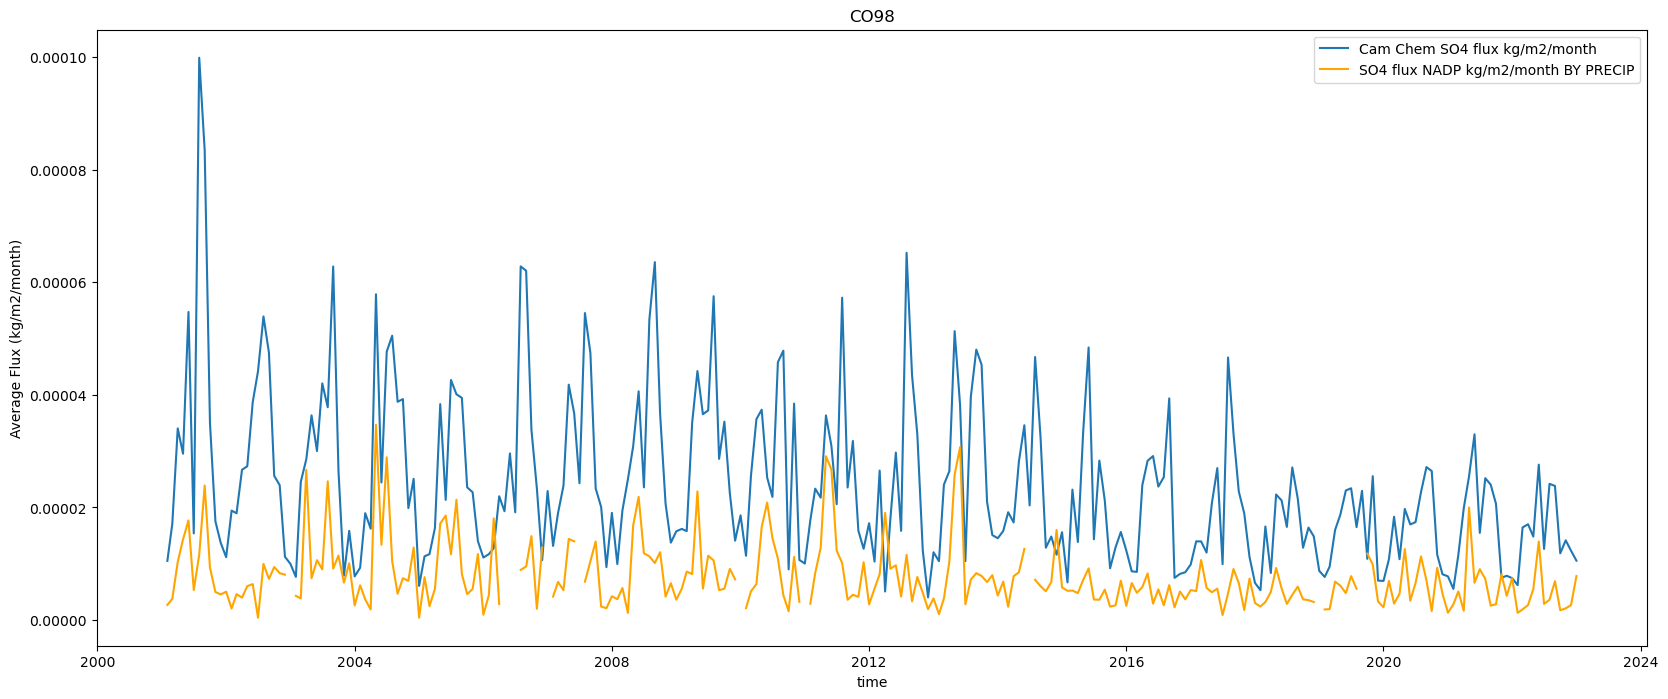

In [121]:
#Select and extract the location
site_sel = 'CO98'
subset_nc = var_sel_so4.sel(siteId=site_sel) #subset_for_CA96 from xarray

#plot the NADP data
ntn_SO4_sub = ntn_SO4_mon.loc[ntn_SO4_mon.siteId == site_sel,] #subset for CA96 from NADP data
ntn_SO4_sub = ntn_SO4_sub.loc[ntn_SO4_sub.time >= "2001-01-15",]

# Plot
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 8), sharey=False, sharex = True)
ax1.plot(time, subset_nc['SO4_total'], label='Cam Chem SO4 flux kg/m2/month')
ax1.plot(time, ntn_SO4_sub['SO4_kgm2_ppt'], label='SO4 flux NADP kg/m2/month BY PRECIP', color = "orange") #precip seems more accurate
#ax2.plot(time, ntn_SO4_CA96['SO4_kgm2_svol'], label='SO4 flux NADP kg/m2/month BY VOLUME')
plt.xlabel('time')
plt.ylabel('Average Flux (kg/m2/month)')
plt.title(site_sel)
ax1.legend()
ax2.legend()
plt.show()

#This looks pretty good considering that:
# a) we are comparing at a monthly average scale (e.g., not daily data)
# b) using a large grid cell size and not interpolating across the grid (just using find nearest function at global model res)
# c) the overall TREND looks good, but the magnitude is higher from the CAM CHEM outputs
# d) the means are calculated differently, the CESM model is presumably a mean based off of daily outputs 
        # and NADP is average of cumulative weekly samples
# e) Cam-Chem delineates 1 month as exactly days 1-30 while NADP month is the approximate month due to when weekly samples were collected

In [122]:
#Now figure out how to merge these files by time.
ntn_SO4_mon_sel = ntn_SO4_mon[['siteId','time', 'SO4_kgm2_ppt', 'SO4_kgm2_svol']] #, 'lat_x', 'lon']]
ntn_so4_nc = ntn_SO4_mon_sel.set_index(["siteId", "time"]).to_xarray()
#ntn_so4_nc

cesm_so4_tot = var_sel_so4['SO4_total']
so4_merge = xr.merge([cesm_so4_tot, ntn_so4_nc])
#so4_merge = so4_merge.dropna(dim = 'time')

/glade/u/apps/jupyterhub/jh-23.11/lib/python3.10/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 264
  result = blockwise(


In [127]:
so4_merge['siteId']

<xarray.DataArray 'siteId' (siteId: 391)>
array(['AB32', 'AB34', 'AB36', ..., 'WY97', 'WY98', 'WY99'], dtype=object)
Coordinates:
  * siteId   (siteId) object 'AB32' 'AB34' 'AB36' ... 'WY97' 'WY98' 'WY99'
    lat      (siteId) float64 57.02 56.07 57.02 -30.63 ... 42.88 42.88 43.82
    lon      (siteId) float64 248.8 248.8 248.8 297.5 ... 251.2 250.0 256.2

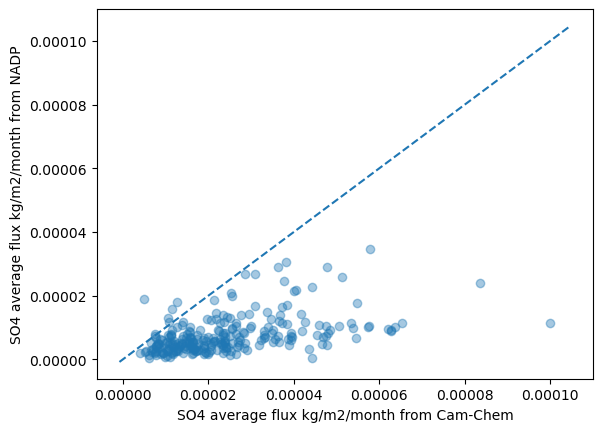

In [130]:
so4_merge_sel = so4_merge.sel(siteId = site_sel)

plt.scatter(so4_merge_sel ['SO4_total'],so4_merge_sel['SO4_kgm2_ppt'], alpha = 0.4)
plt.xlabel('SO4 average flux kg/m2/month from Cam-Chem')
plt.ylabel('SO4 average flux kg/m2/month from NADP')
plt.title(siteId)
abline(1, 0)

KeyboardInterrupt: 

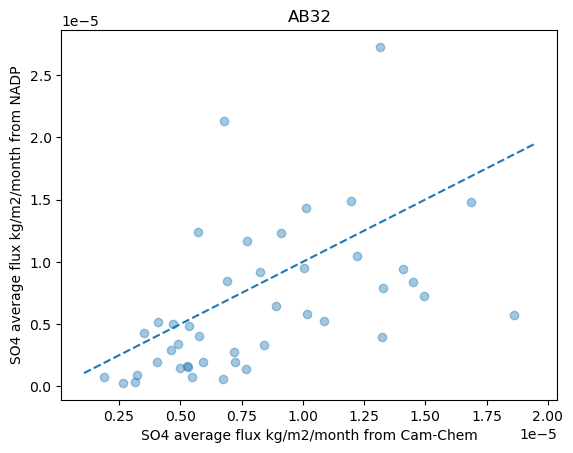

In [104]:
#Create a scatter plot of all data for each site
for i in so4_merge['siteId']:
    #print(i)
    so4_sub = so4_merge.sel(siteId= i.siteId.values) 
    plt.scatter(so4_sub['SO4_total'], so4_sub['SO4_kgm2_ppt'], alpha = 0.4)
    plt.xlabel('SO4 average flux kg/m2/month from Cam-Chem')
    plt.ylabel('SO4 average flux kg/m2/month from NADP')
    plt.title(i.siteId.values)
    abline(1, 0)

In [ ]:
...